This notebook discusses NRLEE nucleosynthesis via Jupyter technology.  As you read through the text, you can execute the code blocks.  You can change input (for example, choose different axis ranges or scaling or select different species to show in the plots).  You can right-click or control-click on figures to save them.  If your current version gets corrupted, don't worry.  Simply quit and download a new copy from GitHub, or start up a new version on Google Colab.

## Table of Contents:

[Introduction](#introduction)<br/>
[Preliminaries](#preliminaries)<br/>
[Model Selection](#model)<br/>
[Full Model](#full)<br/>
[Individual Zones](#individual)<br/>

<a id='introduction'></a>
# Introduction

This notebook allows users to explore NRLEE (Neutron-Rich, Low-Entropy matter Ejector) nucleosythesis in simple models.  NRLEEs are possibly the explosions of dense, white dwarf stars, and the figure below shows the anatomy of a plausible NRLEE model immediately after the explosion.

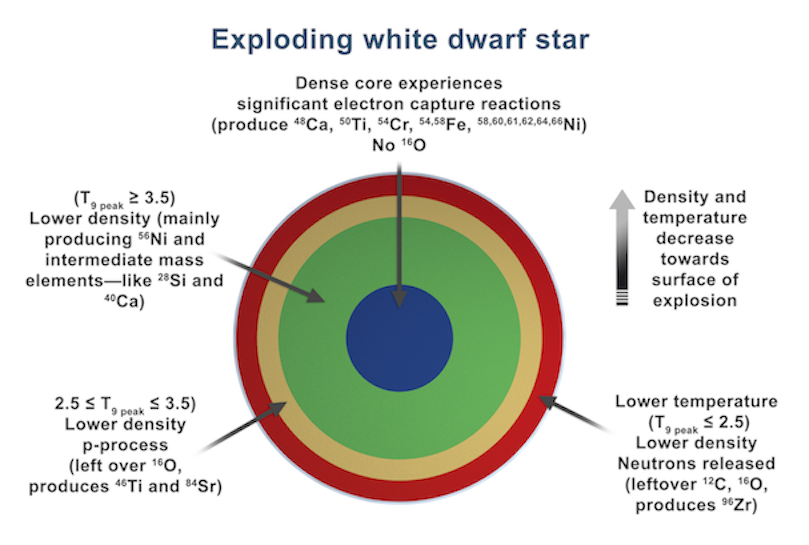

The initial composition of the white dwarf star was set by pre-explosion helium burning, in which case the composition of the star was dominated by the ashes of that burning stage, namely $^{12}$C and $^{16}$O, or, if the initial star was sufficiently massive, by pre-explosion carbon burning, in which case the composition was dominated by $^{16}$, $^{20}$Ne, and $^{24}$Mg.  In either case, the initial composition of the white dwarf was not neutron rich--it had roughly equal numbers of neutrons and protons.  In the densest part of the star, electron-capture reactions during the explosion allowed the matter to become neutron rich.  The low entropy of the matter (few photons per nucleon) then favored production of light, neutron-rich, iron-group isotopes during the explosive burning.  Outside the densest regions of the star, electron-capture reactions were slower during the explosion.  The matter did not become neutron rich and the explosive burning produced less neutron-rich iron-group species than in the denser region and lower-mass species like $^{28}$Si.  At still lower densities, the peak temperatures reached during the explosion were lower, and the material experienced varying degrees of oxygen burning.  In this region, some $\gamma$ processing also occurred.  Finally, in the outermost regions, peak temperatures were still lower and, if the star had initial carbon, this region experience varying degress of explosive carbon burning.  Any initial $^{22}$Ne in this region allowed a burst of neutrons to occur, which produced interesting isotopes like $^{96}$Zr.

The co-production of isotopes showing key isotopic anomalies in primitive meteoritic samples suggests dust that condensed in NRLEE outflows may have been important contributors to the Solar System's inventory of stellar condensate building blocks.  This makes NRLEE nucleosynthesis interesting for cosmochemistry as well as for astrophysics.  This notebook is intended to illustrate NRLEE nucleosynthesis by presenting in a interactive format the results of models computed with the Webnucleo [NRLEE-Nucleosynthesis](https://github.com/mbradle/NRLEE-Nucleosynthesis) project.  Each model comprises a set of single-zone network calculations with varying initial temperature and density.  The initial composition for the models was computed with the Webnucleo [mainlin-nucleosynthesis](https://github.com/mbradle/mainline-nucleosynthesis) and [simple_s_process](https://github.com/mbradle/simple_s_process) projects.  The notebook dowloads data for a given NRLEE model from [OSF](https://osf.io/hz7uv/).  It then uses [wnutils](https://wnutils.readthedocs.io) routines to read, plot, and animate the data.  Users can download selected data as a text file for their own purposes.

<a id='preliminaries'></a>
# Preliminaries

First perform some preliminary operations to set up the notebook.  Once these operations are completed, they need not be repeated when other input is changed.

<a id='General'></a>
## General

Here we import packages and download data.  First, import the necessary packages and download the necessary data.

In [1]:
import sys
!{sys.executable} -m pip install --quiet wnutils

The next step is to import the packages to check for and retrieve the data:

In [2]:
import os, io, requests
from lxml import etree

This notebook uses [wnutils](https://wnutils.readthedocs.io) to analyze the nucleosyntheis [XML](https://www.w3.org/TR/REC-xml/) output, so the next code block imports that package.  It also imports the matplotlib and numpy packages.

In [3]:
import wnutils.xml as wx
import wnutils.multi_xml as mx
import matplotlib.pyplot as plt
import numpy as np

Read in the Solar System abundance data from Lodders from [OSF](https://osf.io/394ws/).  Store the data in a wnutils XML object.

In [4]:
solar = wx.Xml(io.BytesIO(requests.get('https://osf.io/j67qa/download').content))

solar_zone = solar.get_zone_data()

<a id='overabundances'></a>
## Overabundances

This section defines routines for computing overabundances (the abundance relative to the Solar abundance).  Radioactive species overabundances are computed relative to the ultimate daughter (supplied by the rp dictionary).

In [5]:
def calc_overabundances(xml, species, rp=None, zone_xpath=""):
    ov = {}
    x = xml.get_mass_fractions(species, zone_xpath=zone_xpath)

    for sp in species:
        if sp in rp:
            rsp = rp[sp]
        else:
            rsp = sp
        tup = xml.get_z_a_state_from_nuclide_name(rsp)
        ov[sp] = x[sp] / solar_zone['0']['mass fractions'][(rsp, tup[0], tup[1])]
        
    return ov

<a id='polytrope'></a>
## Polytrope

This section sets up the packages, data, and routines for computing the polytrope solutions for white dwarf stars.  First, import the necessary packages.

In [6]:
from scipy.integrate import odeint
from scipy.optimize import root_scalar

Now we define the Lane-Emden equation as two first order derivatives.  Also add a tiny amount to the denominator of one term to avoid overflows and take the absolute value of $\theta$ in taking powers because this is a problem for some n values.  In our treatment, where we are only considering physically relevant solutions (with $\theta \geq 0$), this last point is only an issue near the root when we are root finding.  Near the root, the $\theta^n$ term contributes negligibly to the derivative.

In [7]:
def lane_emden(y, x, n):
    theta, dtheta = y
    dydx = [dtheta, -2. * dtheta / (x + 1.e-300) - np.power(np.abs(theta), n)]
    return dydx

<a id='model'></a>
# Model Selection

In this section, you choose the model for study.  This cell prints out the names of the available models.

In [8]:
models_xml = etree.parse(io.BytesIO(requests.get('https://osf.io/ahvcf/download').content))

models = (models_xml.getroot()).xpath("model")

for m in models:
    print((m.xpath("name"))[0].text, ":", (m.xpath("short_desc"))[0].text)

model1 : T9p=14 at initial density 1.e10 g/cc.  Density tau = 0.1 s.  Tau_0 = 0.3 initial s-process composition.
model2 : T9p=14 at initial density 1.e10 g/cc.  Density tau = 0.2 s.  Tau_0 = 0.3 initial s-process composition.
model3 : T9p=14 at initial density 1.e10 g/cc.  Density tau = 0.5 s.  Tau_0 = 0.3 initial s-process composition.
model4 : T9p=10 at initial density 1.e10 g/cc.  Density tau = 0.1 s.  Tau_0 = 0.3 initial s-process composition.
model5 : T9p=10 at initial density 1.e10 g/cc.  Density tau = 0.2 s.  Tau_0 = 0.3 initial s-process composition.
model6 : T9p=10 at initial density 1.e10 g/cc.  Density tau = 0.5 s.  Tau_0 = 0.3 initial s-process composition.


Choose the model.  The code block then checks whether the data for the model exist locally, and, if not, retrieves and unpacks them from [OSF](https://osf.io/hz7uv/). If you would like to suppress the download statistics, add a -s to the curl command after the -L.  The download and file decompression can take a few minutes, so please be patient.

In [9]:
model = 'model1'

if not os.path.exists(model):
    xpath_str = "model[name = " + "'{}'".format(model) + "]"
    f = open("url.txt", "w")
    f.write(models_xml.getroot().xpath(xpath_str)[0].xpath("url")[0].text)
    f.close()
    !curl -o model.tar.gz -J -L `cat url.txt`
    !tar zxf model.tar.gz

<a id='full'></a>

# The Full Model

The exploding white dwarf star was simulated by taking an initial composition from an s-process calculation and considering that composition at a variety of initial densities.  The matter was imagined to be heated to an initial temperature that was a function of the initial density and then allowed to expand and cool on an exponential timescale.  The first section in what follows shows the results from these calculations.  The second section applies the Lane-Emden equations to create a simple model of a white dwarf star with the resulting nucleosynthesis yields.

Begin by reading the data for the full model.

In [10]:
full = wx.Xml(model + '/full.xml')

## Initial density

Retrieve key properties from a chosen density range from the full XML input.  The default is all zones, but the commented out line shows how to select a more limited set that would ultimately represent a white dwarf star with a lower central density.

In [11]:
zone_xpath = ""
#zone_xpath = "[optional_properties/property[@name = 'rho_0'] < 2.0e+09]"

props = full.get_properties_as_floats(['rho_0', 't9_0'], zone_xpath=zone_xpath)

Retrieve the initial (peak) temperature versus initial density and plot them against each other.

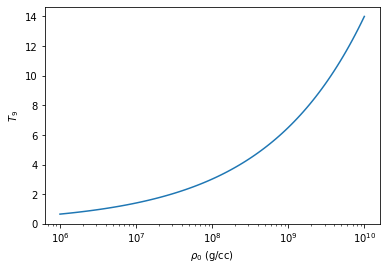

In [12]:
plt.plot(props['rho_0'], props['t9_0'])
plt.xscale('log')
plt.xlabel('$\\rho_0$ (g/cc)')
plt.ylabel('$T_9$')
plt.show()

Plot the final electron fraction $Y_e$ as a function of the initial density.  At high density, electron-capture reactions are sufficiently fast during the explosion that $Y_e$ reduces down to values well below the initial value near 0.5.

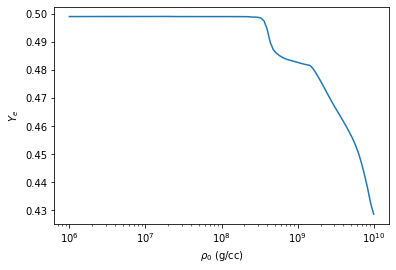

In [13]:
y = full.get_all_abundances_in_zones(zone_xpath=zone_xpath)
ye = np.sum(np.dot(np.swapaxes(y, 1, 2), np.arange(y.shape[1])), axis=1)
plt.plot(props['rho_0'], ye)
plt.xscale('log')
plt.xlabel('$\\rho_0$ (g/cc)')
plt.ylabel('$Y_e$')
plt.show()

Choose species to study. Also, here define a daughters dictionary to permit the overabundance code to compute overabundance of a radioactive species relative to its ultimate daughter. The dictionary can include species other than the ones chosen for study, but any radioactivity in the species list must have an entry in the daughters dictionary.  Also retrieve the species mass fractions and latex names for later use.

In [14]:
species = ['ca40', 'ca41', 'ca42', 'ca43', 'ca44', 'ca46', 'ca48']
daughters = {'ca41': 'k41', 'fe60': 'ni60'}
lnames = full.get_latex_names(species)
x = full.get_mass_fractions(species, zone_xpath=zone_xpath)

Plot mass fractions as a function of the initial density.

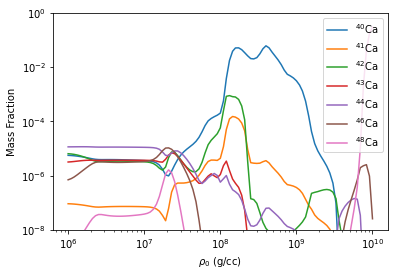

In [15]:
for sp in species:
    plt.plot(props['rho_0'], x[sp], label=lnames[sp])
    
plt.xscale('log')    
plt.yscale('log')
plt.ylim([1.e-8,1])
plt.xlabel('$\\rho_{0}$ (g/cc)')
plt.ylabel('Mass Fraction')
plt.legend()
plt.show()

Plot the overabundances (abundance relative to the Solar abundance) as a function of the initial density.

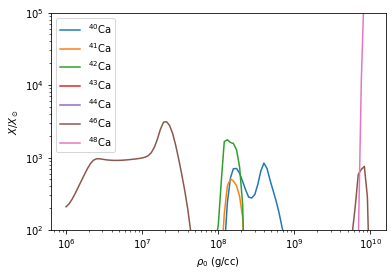

In [16]:
ov = calc_overabundances(full, species, rp = daughters, zone_xpath = zone_xpath)
for sp in ov:
    plt.plot(props['rho_0'], ov[sp], label=lnames[sp])
    
plt.xscale('log')    
plt.yscale('log')
plt.ylim([100,1.e5])
plt.xlabel('$\\rho_{0}$ (g/cc)')
plt.ylabel('$X / X_\\odot$')
plt.legend()
plt.show()

## Convert to a white dwarf model

Convert the initial densities to a white-dwarf star model by applying a polytropic solution (a solution to the Lane-Emden equation).  Choose the total mass in solar masses (1.4 Solar masses is the typical Chandrasekhar limit, which is the theoretical maximum limit on a stable white dwarf star mass for matter with equal numbers of neutrons and protons) and the polytropic index, which can range $0 < n < 5$.  The smaller $n$ is, the more uniform the density is in the model.  The central density is determined from the XML input.  We store the densities and flip them (to go from high to low) to align them with interior mass coordinates later.  If you would like to change the central density of the white dwarf model, change the *zone_xpath* above.

In [17]:
M = 1.4
n = 3

Compute the interior mass coordinates based on the chosen index and total mass.  The central density is determined from the XML input.  We store the densities and flip them to align them with the interior mass.  Also compute shell thicknesses.

In [18]:
rhos = np.flip(props['rho_0'])
rho_c = rhos[0]

# Here define the root function (solve to a part in 10^6 to suppress unnecessary warnings).

def f(x, phi_0, n):
    assert(n > 0 and n < 5)
    y0 = [1., 0.]
    xsol = np.linspace(0, x, 2)
    sol = odeint(lane_emden, y0, xsol, args=(n,))
    result = sol[sol.shape[0]-1, 0] - phi_0
    if abs(result) < 1.e-6:
        result = 0
    return result

# Solve for the masses at the various density points.

Ms = []
dM = []

r_sol = root_scalar(f, args=(0, n), x0 = 0, x1 = 1)
xsi_1 = r_sol.root
x = np.linspace(0, xsi_1, 101)
msol = odeint(lane_emden, [1., 0.], x, args=(n,))
dphi_1 = msol[msol.shape[0]-1, 1]

for r in rhos:
    phi_0 = (r / rho_c)**(1./n)
    r_sol = root_scalar(f, args=(phi_0, n), x0 = 0, x1 = 1)
    xsi = r_sol.root
    x = np.linspace(0, xsi, 101)
    msol = odeint(lane_emden, [1., 0.], x, args=(n,))
    dphi = msol[msol.shape[0]-1, 1]
    Ms.append(M * xsi**2 * dphi / (xsi_1**2 * dphi_1))
    
Ms[0] = 0  # Reset to avoid slightly non-zero value due to numerical inaccuracies.

for i in range(len(Ms)-1):
    dM.append(Ms[i+1] - Ms[i])
    
dM.append(M - Ms[len(Ms)-1])

Plot the density as a function of mass.

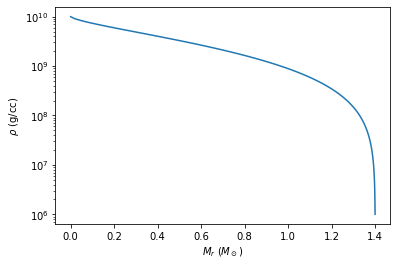

In [19]:
plt.plot(Ms, rhos)
plt.xlabel('$M_r\\ (M_\\odot)$')
plt.ylabel('$\\rho$ (g/cc)')
plt.yscale('log')
plt.show()

Plot the final electron fraction $Y_e$ as a function of the interior mass coordinate.  The inner regions, owing to their high densities, experience the most electron capture and so have the lowest final $Y_e$ values.

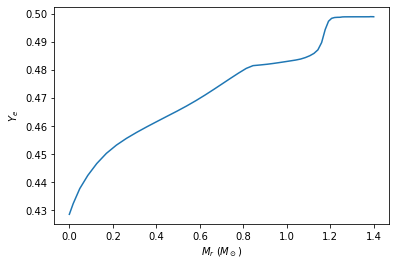

In [20]:
plt.plot(Ms, np.flip(ye))
plt.xlabel('$M_r\\ (M_\\odot)$')
plt.ylabel('$Y_e$')
plt.show()

Choose species to study.  Also, here define a daughters dictionary to permit the overabundance code to compute overabundance of a radioactive species relative to its ultimate daughter.  The dictionary can include species other than radioactive ones chosen for study, but any radioactivity in the *species* list must have an entry in the *daughters* dictionary.

In this cell, we also create the latex names for the species and flip the species arrays to align them with the masses.

In [21]:
species = ['ti44', 'ti46', 'ti47', 'ti48', 'ti49', 'ti50', 'cr48']
daughters = {'ti44': 'ca44', 'cr48': 'ti48', 'fe60': 'ni60'}

lnames = full.get_latex_names(species)

x = full.get_mass_fractions(species, zone_xpath = zone_xpath)
xf = {}
for sp in species:
    xf[sp] = np.flip(x[sp])

Plot the mass fractions as a function of the interior mass coordinate.

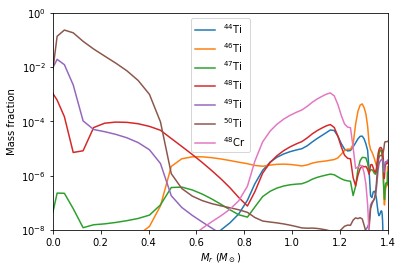

In [22]:
for sp in xf:
    plt.plot(Ms, xf[sp], label=lnames[sp])
    
plt.yscale('log')
plt.xlim([0,1.4])
plt.ylim([1.e-8,1])
plt.xlabel('$M_r\\ (M_\\odot)$')
plt.ylabel('Mass fraction')
plt.legend()
plt.show()

Now plot the overabundances as a function of interior mass.  Note that the overabundance of a radioactive species is computed relative to its stable daughter.

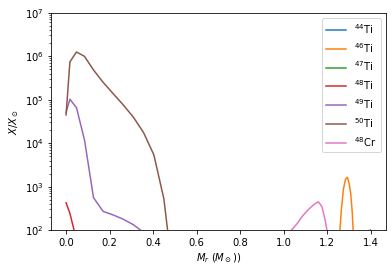

In [23]:
ov = calc_overabundances(full, species, rp = daughters, zone_xpath = zone_xpath)
for sp in ov:
    plt.plot(Ms, np.flip(ov[sp]), label=lnames[sp])
    
plt.yscale('log')
plt.ylim([100,1.e7])
plt.xlabel('$M_r\\ (M_\\odot)$)')
plt.ylabel('$X / X_\\odot$')
plt.legend()
plt.show()

Save the mass fractions as a function of mass coordinate $M_r$ and shell mass $dM$ (in Solar masses) in file *my_file*.  Change the name from the default *my_file.txt* according to your purposes.  The file will be written in the local directory.  On Google Colab, click on the file tab on the far left and download.  To also print out the data, change *print_out* to *True*.

In [24]:
my_file = 'my_file.txt'

print_out = False

f = open(my_file, 'w')

f.write('Mr\t' + 'dM\t' + '\t'.join(species) + '\n')

for i in range(len(Ms)):
    x = []
    for sp in xf:
        x.append('{:.4e}'.format(xf[sp][i]))
        
    f.write('{:.4e}'.format(Ms[i]) + '\t' + '{:.4e}'.format(dM[i])+ '\t' + '\t'.join(x) + '\n')
    
f.close()
    
if print_out:
    f = open(my_file, 'r')
    for line in f:
        print(line)

<a id='individual'></a>

# Individual Zones

This section allows you to explore the nucleosynthesis of individual zones during the modeled explosion.  First choose an initial density for the model and select the output file from the *zones* subdirectory. You can look at the downloaded *zones* directory to see the files (on Google Colab, click the folder icon to the left and navigate to the *zones* subdirectory).  Alternatively, uncomment the commands (remove the leading *#* in each line) in the next code block and run the cell.  You will see a list of available files.

In [25]:
#files = os.listdir(model + '/zones')
#xfiles = [float(f.split('.xml')[0]) for f in files]
#for x in sorted(xfiles):
#    print('{:.2e}.xml'.format(x))

Select the zone of interest by choosing the appropriate XML file.  The name of the file gives the initial mass density.

In [26]:
my_file = '2.09e+07.xml'

my_xml = wx.Xml(model + '/zones/' + my_file)

Plot the temperature in billions of Kelvins as a function of time.  Adjust the plot parameters according to your purposes.  You may choose other properties to plot (such as the density, *'rho'*).  For a linear scale, choose *'linear'* instead of *'log'*.

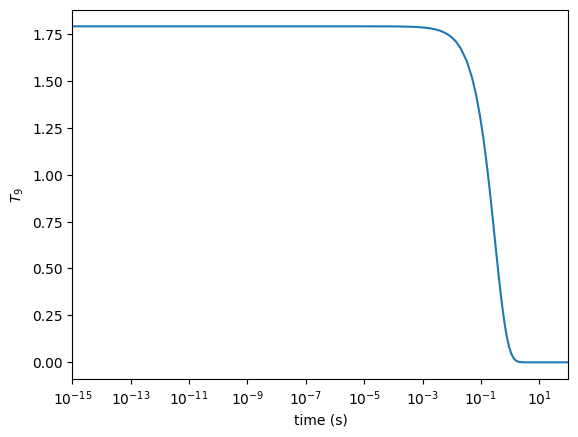

In [27]:
my_xml.plot_property_vs_property('time', 't9', xscale = 'log', xlim = [1.e-15,100], xlabel = 'time (s)',
                                 ylabel = '$T_9$')

Plot the electron fraction $Y_e$ as a function of time.  Adjust the plot parameters as needed.

Text(0, 0.5, '$Y_e$')

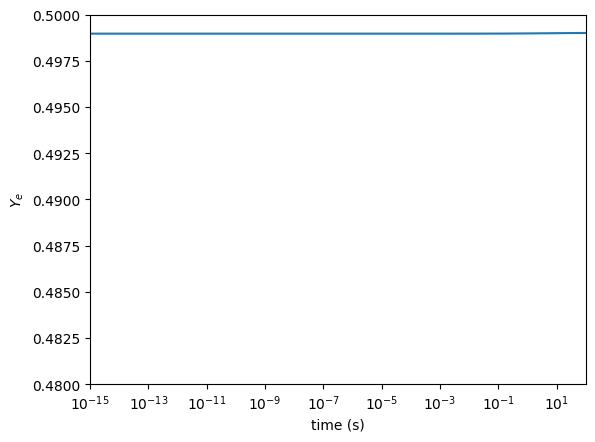

In [28]:
props = my_xml.get_properties_as_floats(['time', 't9', 'rho'])
y = my_xml.get_all_abundances_in_zones()
ye = np.sum(np.dot(np.swapaxes(y, 1, 2), np.arange(y.shape[1])), axis=1)

plt.plot(props['time'], ye)
plt.xscale('log')
plt.xlim([1.e-15,100])
plt.ylim([0.48,0.5])
plt.xlabel('time (s)')
plt.ylabel('$Y_e$')

Now choose species to plot.  Be sure to include daughters for any radioactive species to be able to calculate overabundances.

In [29]:
species = ['ca40', 'ca41', 'ca42', 'ca43', 'ca44', 'ca45', 'ca46', 'ca47', 'ca48']
daughters = {'ca41': 'k41', 'ca45': 'sc45', 'ca47': 'ti47'}

lnames = my_xml.get_latex_names(species)

Plot the species mass fractions.

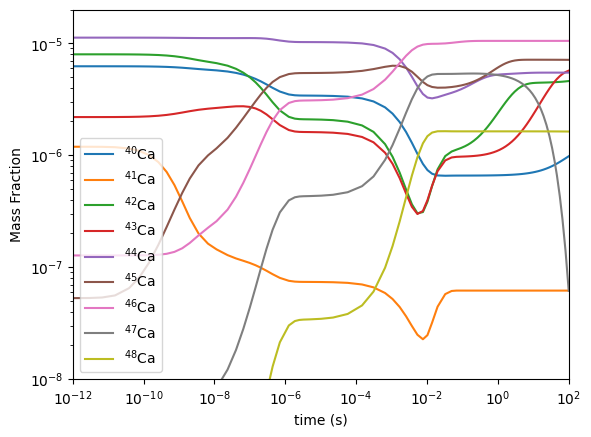

In [30]:
my_xml.plot_mass_fractions_vs_property('time', species, xscale = 'log', yscale = 'log', use_latex_names = True,
                                      xlim = [1.e-12, 100], ylim = [1.e-8, 2.e-5], xlabel = 'time (s)')

Now plot the overabundances as a function of time.

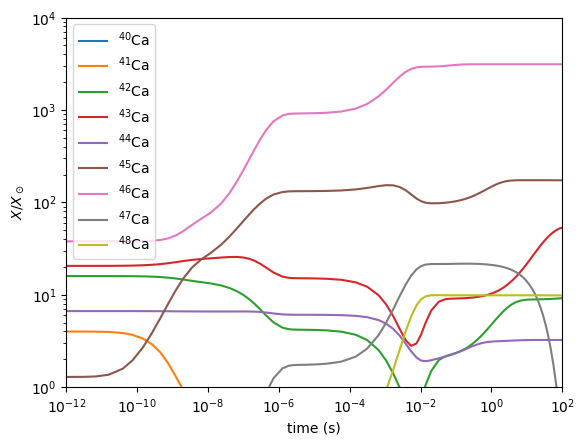

In [31]:
ov = calc_overabundances(my_xml, species, rp = daughters)
for sp in ov:
    plt.plot(props['time'], ov[sp], label=lnames[sp])
    
plt.xscale('log')
plt.yscale('log')
plt.xlim([1.e-12,100])
plt.ylim([1, 1.e4])
plt.xlabel('time (s)')
plt.ylabel('$X / X_\\odot$')
plt.legend()
plt.show()

Plot the neutron number density as a function of time.

Text(0, 0.5, 'Neutron number density (per cc)')

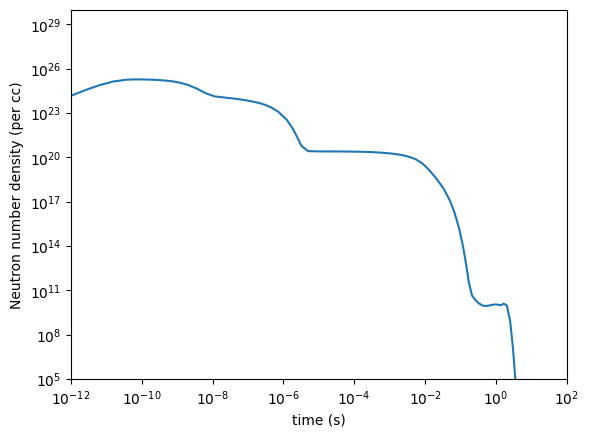

In [32]:
props = my_xml.get_properties_as_floats(['time', 't9', 'rho'])
x = my_xml.get_mass_fractions(['n'])
n_n = x['n'] * props['rho'] * 6.02e23

plt.plot(props['time'], n_n)
plt.xscale('log')
plt.yscale('log')
plt.xlim([1.e-12,100])
plt.ylim([1.e5,1.e30])
plt.xlabel('time (s)')
plt.ylabel('Neutron number density (per cc)')

Save selected data to a file. Change the name from the default *my_zone_file.txt* according to your purposes. The file will be written in the local directory. On Google Colab, click on the file tab on the far left and download. To also print out the data, change print_out to True.

In [33]:
my_zone_file = 'my_zone_file.txt'

print_out = False

f = open(my_zone_file, 'w')

f.write('Output from ' + model + '/zones/' + my_file + '\n')

my_props = ['time', 't9', 'rho']
x = my_xml.get_mass_fractions(species)

line = ''
for p in props:
    line += p + '\t'
    
for sp in x:
    line += sp + '\t'
    
f.write(line + '\n')

for i in range(len(x[species[0]])):
    line = ''
    for p in props:
        line += '{:.4e} \t'.format(props[p][i])
    for sp in x:
        line += '{:.4e} \t'.format(x[sp][i])
    f.write(line + '\n')
            
f.close()
    
if print_out:
    f = open(my_zone_file, 'r')
    for line in f:
        print(line)